# **LSTM predictions**

## 1. **Imports**

In [138]:
import torch
from torch.utils.data.dataset import Dataset, Subset
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import torch.nn as nn
from tqdm import tqdm
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, f1_score

## 2. **Utils**

### 2.1 Creation of the dataset

#### Generate segments of continuous time from the data

In [15]:
def generate_segments(df, time_column='timestamp', max_gap_minutes=30):
    """
    Splits a DataFrame into multiple continuous segments based on a time threshold.
    
    Args:
        df (pd.DataFrame): The input dataframe containing bus delay data.
        time_column (str): The name of the datetime column.
        max_gap_minutes (int): The maximum allowed gap between two rows to stay in the same segment.
        
    Returns:
        list: A list of DataFrames, where each DataFrame is a continuous segment.
    """
    
    # Ensure the data is sorted by time 
    df[time_column] = pd.to_datetime(df[time_column])
    df = df.sort_values(time_column).reset_index(drop=True)
    
    # Calculate the time difference between consecutive rows
    df['time_diff'] = df[time_column].diff()
    
    # Identify where the gap is larger than our threshold (30 min)
    # The first row will have a NaT diff, we fill it with 0 to keep it in the first segment
    mask_new_segment = df['time_diff'] > pd.Timedelta(minutes=max_gap_minutes)
    
    # Create a segment ID by cumulatively summing the masks
    df['segment_id'] = mask_new_segment.cumsum()
    
    # Split the dataframe into a list of segments
    segments = [group.drop(columns=['time_diff', 'segment_id']) 
                for _, group in df.groupby('segment_id')]
    
    print(f"Total segments found: {len(segments)}")
    
    for i,s in enumerate(segments) :
        print(f"Start of the segment nb {i} : ", s["timestamp"].iloc[0])
        print(f"End of the segment nb {i} : ", s["timestamp"].iloc[-1])
        s = s.select_dtypes(include=[np.number]).astype(np.float32)
    return segments #, segments_with_timestamps


#### Plot the segments

In [16]:
segments_names = ['June', 'August', 'October', 'December']
def plot_segments(segments, segments_names=segments_names):
        """
        Plots each segment in a vertical column to visualize 
        differences in delay patterns and variance.
        """
        num_segments = len(segments)
        # Create a figure with one column and 'n' rows
        fig, axes = plt.subplots(num_segments, 1, figsize=(12, 4 * num_segments), sharex=False)
        
        # If there's only one segment, axes is not an array, so we wrap it
        if num_segments == 1:
            axes = [axes]

        for i, seg in enumerate(segments):
                # Create x-axis values: (index / 48) + 8 to get fractional days starting at 8
                x_days = (np.arange(len(seg)) / 48) + 8
                
                axes[i].plot(x_days, seg['avg_delay'].values, color='steelblue', lw=1.5)
                
                # Formatting titles and labels
                axes[i].set_title(f"Segment {segments_names[i]} - Delay Evolution (Starting Day 8)", fontsize=12)
                axes[i].set_ylabel("Delay (seconds)")
                axes[i].set_xlabel("Time (Days)")
                
                # Improve grid for readability (marks every full day)
                axes[i].grid(True, linestyle='--', alpha=0.6)

                # Calculate local stats to help diagnose the loss problem
                mean_val = seg['avg_delay'].mean()
                std_val = seg['avg_delay'].std()
                axes[i].annotate(f"Mean: {mean_val:.2f}\nStd: {std_val:.2f}", 
                                xy=(0.02, 0.8), xycoords='axes fraction',
                                bbox=dict(boxstyle="round", fc="white", alpha=0.8))


        plt.tight_layout()
        plt.show()


### 2.2 Training functions for the model 

In [17]:
def train_one_epoch(model, optimizer, criterion, train_loader, device, epoch, tf_ratio=0.5):
    """Performs one epoch of training with optional teacher forcing."""
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    
    for x_past, target_window, _ in pbar:
        x_past, target_window = x_past.to(device), target_window.to(device)
        
        optimizer.zero_grad()
        
        # target_window contains [delay, exog1, exog2...] for n future steps
        y_pred = model(x_past, target_window, teacher_forcing_ratio=tf_ratio)
        y_true = target_window[:, :, model.target_idx].unsqueeze(-1)
        
        loss = criterion(y_pred, y_true)
        loss.backward()
        optimizer.step()
        
        current_loss = loss.item()
        total_loss += current_loss
        pbar.set_postfix(train_batch_loss=current_loss)

    return total_loss / len(train_loader)


In [18]:
def validate(model, criterion, target_idx, test_loader, device, epoch):
    """ Evaluates the model on the validation set without teacher forcing. """
    model.eval()
    total_val_loss = 0
    pbar = tqdm(test_loader, desc=f"Epoch {epoch} [Val]", unit="batch")
    with torch.no_grad():
        for x_past, target_window, _ in pbar:
            x_past, target_window = x_past.to(device), target_window.to(device)
            
            y_true = target_window[:, :, target_idx].unsqueeze(-1)
            # During validation, teacher forcing ratio is always 0
            y_pred = model(x_past, target_window, teacher_forcing_ratio=0)
            loss = criterion(y_pred, y_true)
            
            current_loss = loss.item()
            total_val_loss += current_loss
            pbar.set_postfix(val_loss=current_loss)
            
    return total_val_loss / len(test_loader)

In [19]:

def save_training_curve(train_losses, val_losses, output_dir, id, L, n, layers, hidden_dim, lr):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label='Training Loss', color='blue', lw=2)
    plt.plot(epochs, val_losses, label='Validation Loss', color='orange', lw=2)
    
    plt.title('Training and Validation Loss Over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    save_path = os.path.join(output_dir, f'curves_{id}_{L}_{n}_{layers}_{hidden_dim}_{lr}.png')
    plt.savefig(save_path)
    plt.close()
    print(f"Training curve saved at: {save_path}")

### 2.3 Inference

In [20]:
def denormalize_prediction(y_pred, scaler, target_idx, input_dim):
    """ Applies inverse normalization to the predicted values in order to retrieve original scale values. """
    y_pred_cpu = y_pred.detach().cpu()
    batch_size, n_steps, _ = y_pred_cpu.shape
    dummy_input = np.zeros((batch_size * n_steps, input_dim),dtype=np.float32)
    dummy_input[:, target_idx] = y_pred_cpu.flatten()
    inverse_dummy = scaler.inverse_transform(dummy_input)
    return inverse_dummy[:, target_idx].reshape(batch_size, n_steps).astype(np.float32)

In [149]:
def evaluate_to_metrics_by_horizon(model, test_loader, scaler, device, target_idx, input_dim, disruption_thr, n_horizons=12, output_filename="data_metrics_horizons.csv"):
    model.eval()
    all_preds = [[] for _ in range(n_horizons)]
    all_trues = [[] for _ in range(n_horizons)]
    
    with torch.no_grad():
        for x_past, target_window, _ in test_loader:
            x_past, target_window = x_past.to(device), target_window.to(device)
            
            # Inference
            y_pred = model(x_past, target_window, teacher_forcing_ratio=0) # [batch, n_horizons, 1]
            y_true = target_window[:, :n_horizons, target_idx].unsqueeze(-1) # [batch, n_horizons, 1]
            
            # Unstandardisation
            y_pred_denorm = denormalize_prediction(y_pred, scaler, target_idx, input_dim)
            y_true_denorm = denormalize_prediction(y_true, scaler, target_idx, input_dim)
            
            # Extract prediction and true values for each horizon and store them
            for h in range(n_horizons):
                all_preds[h].extend(y_pred_denorm[:, h].flatten())
                all_trues[h].extend(y_true_denorm[:, h].flatten())

    metrics_history = []

    for h in range(n_horizons):
        preds_h = np.array(all_preds[h])
        trues_h = np.array(all_trues[h])
        
        # --- Regression Metrics ---
        mse = mean_squared_error(trues_h, preds_h)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(trues_h, preds_h)
        r2 = r2_score(trues_h, preds_h)

        # --- Classification Metrics ---
        binary_trues = (trues_h > disruption_thr).astype(int)
        binary_preds = (preds_h > disruption_thr).astype(int)
        
        precision = precision_score(binary_trues, binary_preds, zero_division=0)
        recall = recall_score(binary_trues, binary_preds, zero_division=0)
        f1 = f1_score(binary_trues, binary_preds, zero_division=0)
        
        # --- Add metrics for horizon h+1 ---
        metrics_history.append({
            'Horizon': h + 1,
            'MSE': round(mse, 4),
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4),
            'R2': round(r2, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1': round(f1, 4)
        })
    
    df_metrics = pd.DataFrame(metrics_history)
    df_metrics.to_csv(output_filename, index=False)
    
    print(f"Export done : {n_horizons} horizons saved in {output_filename}")
    return df_metrics

## 3. **Data loading and explanation**

In this section, we load the data from a previously made csv in the notebook **Dataset_for_model_training.ipynb**.

Here is a little description of the columns of dataset :

### 3.1 Time columns

| **column name** | **Description** | **format** |
|---|-------|-------------|
| **timestamp** | Date timestamp. | pandas.datetime.Timestamp, 'YYYY-MM-DD hh:mm:ss' |
| **hour** | Value of the hour of the day between 0 and 23 to which we applied a sinus cyclic transformation | float between -1 and 1 |
| **day_of_week** | Value of the day of the week between 0 and 6 to which we applied a sinus cyclic transformation | float between -1 and 1 |
| **month** | Value of the month of the year between 1 and 12 to which we applied a sinus cyclic transformation | float between -1 and 1 |
| **is_weekend** | 1 if the corresponding timestamp is a Saturday or a Sunday else 0 | binary |
| **is_holiday** | 1 if the corresponding timestamp corresponds to a holiday date in the US in 2017 | binary |

### 3.2 Event columns

| **column name** | **Description** | **format** |
|---|-------|-------------|
| **FLATBUSH AV/PROSPECT PARK ENT** | a row of this column is 1 if there is an event occuring at the place  FLATBUSH AV/PROSPECT PARK ENT during the corresponding timestamp | binary |
| **LIVINGSTON ST/NEVINS ST** | a row of this column is 1 if there is an event occuring at the place  LIVINGSTON ST/NEVINS ST during the corresponding timestamp | binary |
| **FLATBUSH AV/BERGEN ST** | a row of this column is 1 if there is an event occuring at the place  FLATBUSH AV/BERGEN ST during the corresponding timestamp | binary |
| **CADMAN PLZ W/MONTAGUE ST** | a row of this column is 1 if there is an event occuring at the place  CADMAN PLZ W/MONTAGUE ST during the corresponding timestamp | binary |
| **FLATBUSH AV/PLAZA ST E** | a row of this column is 1 if there is an event occuring at the place  FLATBUSH AV/PLAZA ST E during the corresponding timestamp | binary |

### 3.3 Weather columns

| **column name** | **Description** | **format** |
|---|-------|-------------|
| **temperature_c** | Temperature in NYC in °C | float |
| **precipitation** | Amount of precipitation in NYC | positive float |
| **windspeed_kmh** | Windspeed in km/h | positive float |

### 3.4 Delay columns

| **column name** | **Description** | **format** |
|---|-------|-------------|
| **avg_delay** | Average delay in minutes on the B41 bus line at the corresponding timestamp | float |
| **dayly_lag** | Average delay in minutes on the B41 bus line at the corresponding timestamp one day ago | positive float |
| **weekly_lag** | Average delay in minutes on the B41 bus line at the corresponding timestamp one week ago | positive float |

### 3.5 Load the data

In [145]:
bus_df = pd.read_csv("dataset_LSTM.csv", index_col=0, sep = ";") 
bus_df.head(3)

,timestamp,FLATBUSH AV/PROSPECT PARK ENT,LIVINGSTON ST/NEVINS ST,FLATBUSH AV/BERGEN ST,CADMAN PLZ W/MONTAGUE ST,FLATBUSH AV/PLAZA ST E,avg_delay,temperature_c,precipitation,windspeed_kmh,month,week_day,hour,is_weekend,is_holiday,dayly_lag,weekly_lag
336,2017-06-08 00:00:00,0,0,0,0,0,7.100000,13.80,0.0,8.6,-0.5,-0.016601,0.500000,0,1,6.605263,73.181746
337,2017-06-08 00:30:00,0,0,0,0,0,2.557778,13.35,0.0,8.0,-0.5,-0.016601,0.500000,0,1,4.042500,2.930392
338,2017-06-08 01:00:00,0,0,0,0,0,1.746296,12.90,0.0,7.4,-0.5,-0.016601,0.741782,0,1,1.522917,0.852083


## 4. **Creation of the dataset**

### 4.1 Load the prepared data from .csv file

### 4.2 Split the data into 4 continuous segments

The dataset we are using features data from **june, august, october and december** 2017. Because of the need sequential nature of the training data for LSTMs, a particular effort is done to split the data from the dataframe *bus_df* into 4 continuous segments.

In [98]:
segments = generate_segments(bus_df, time_column='timestamp', max_gap_minutes=30) # cf Utils section

Total segments found: 4
Start of the segment nb 0 :  2017-06-08 00:00:00
End of the segment nb 0 :  2017-06-30 23:30:00
Start of the segment nb 1 :  2017-08-08 00:00:00
End of the segment nb 1 :  2017-08-29 19:30:00
Start of the segment nb 2 :  2017-10-08 00:00:00
End of the segment nb 2 :  2017-10-31 23:30:00
Start of the segment nb 3 :  2017-12-08 00:00:00
End of the segment nb 3 :  2017-12-31 23:30:00


Let's now vizualize the 4 segments (june, august, october, december)

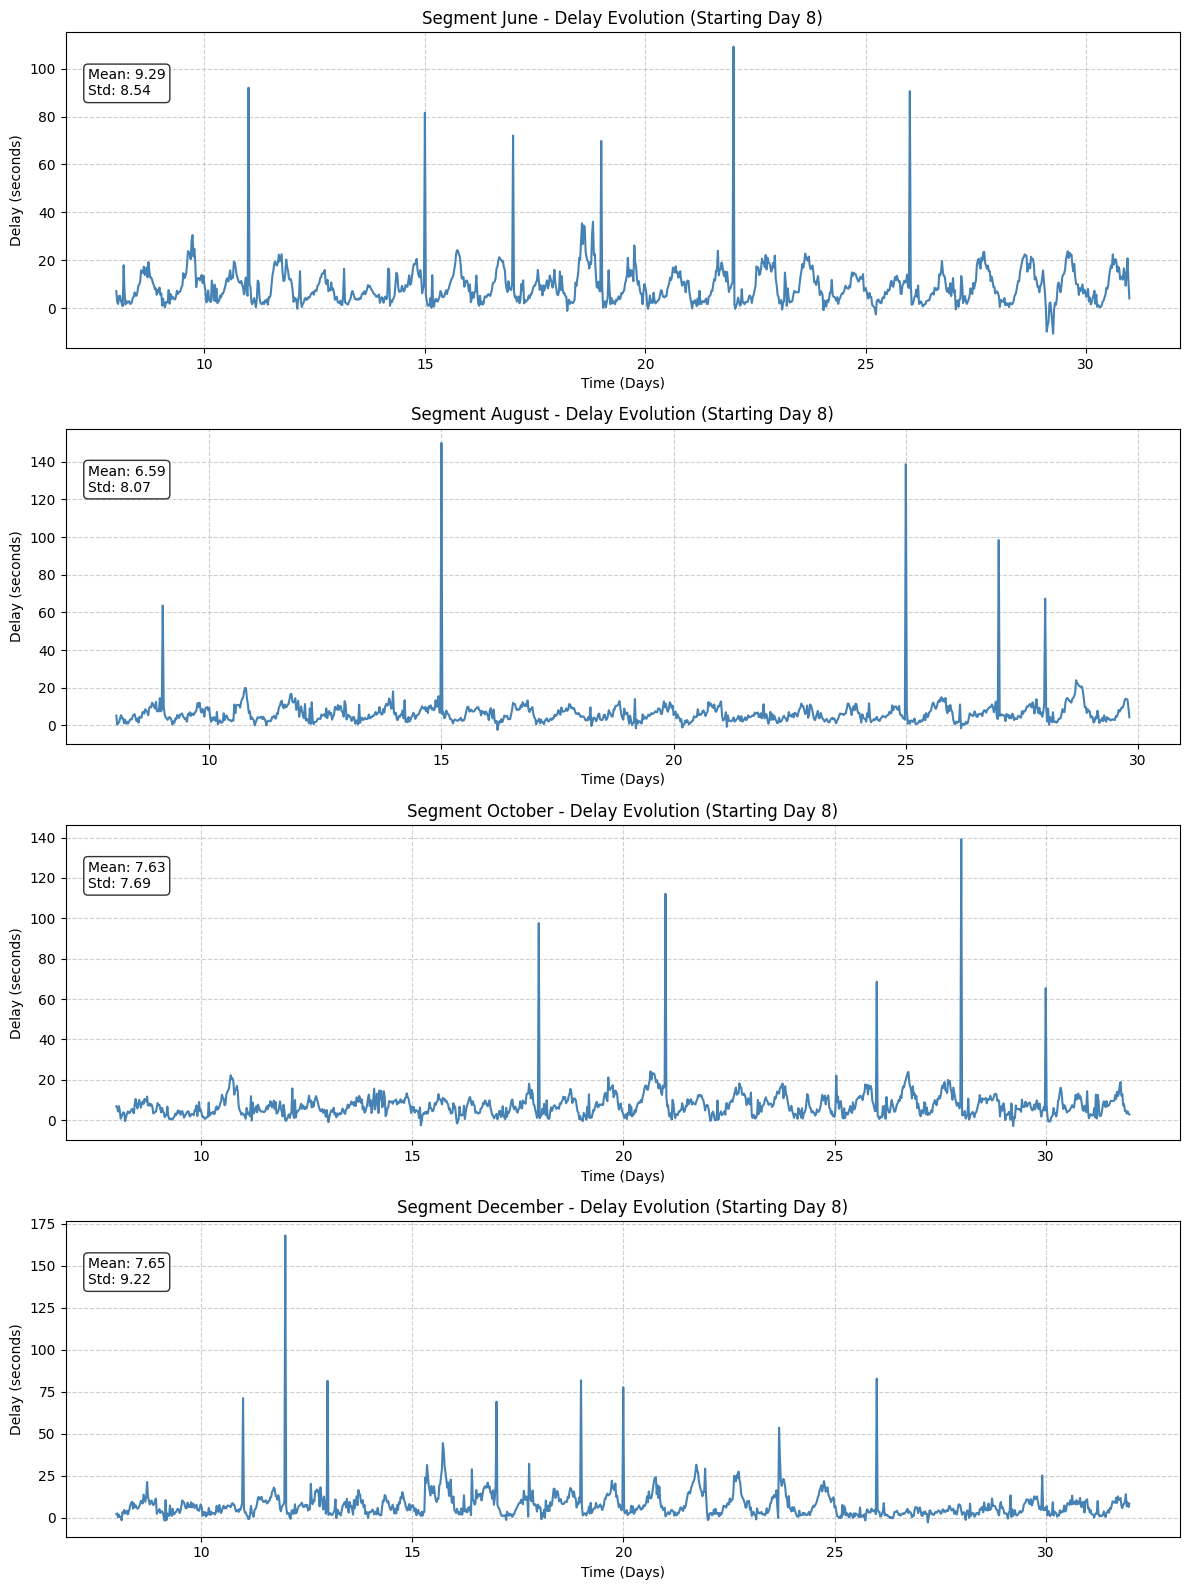

In [99]:
plot_segments(segments)

We can notice on these graphs a oscillatory behaviour with a daily period. Furthermore, some big spikes of delay occur from time to time.

### 4.3 Definition of the BusSequences dataset

Let us now define our dataset class BusSequences from which we will get the sequences with adequat length to train our LSTM model.   

Note that the length of the "lookback" sequence (number of half hours) is managed by a parameter **L** so that this code enables different sequence length. This parameter has however to be fixed for training and can considered hyperparameter of the model.  

Another parameter **n** is used to control the length (number of half hours) of the prediction.   


In [100]:
class BusSequences(Dataset):
    def __init__(self, data_segments, L, n, scaler = None):
        self.L = L # Lookback window size : how many past points to use for prediction
        self.n = n # Future window size : how many future points to predict
        self.segments = data_segments # List of DataFrames, each representing a continuous segment of data
        self.numeric_segments = [s.select_dtypes(include=[np.number]).astype(np.float32) for s in self.segments] # Only keep numeric columns for modeling

        self.valid_indices = [] # List of tuples (segment_index, start_index) indicating valid starting points for sequences. This indices depend on L and n !
        self.column_to_idx = {} # Mapping from column names to their index in the numeric segments. 

        self.scaler = scaler # Scaler used for normalization, fitted on the training set to avoid data leakage. 
        
        for seg_idx, seg in enumerate(self.numeric_segments):
            # We can only start a sequence if there are enough points left
            num_samples = len(seg) - (L + n) + 1
            for i in range(num_samples):
                self.valid_indices.append((seg_idx, i))

        for i, c in enumerate(self.numeric_segments[0].columns):
            self.column_to_idx[c] = i

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        seg_idx, start = self.valid_indices[idx]
        seg_num = self.numeric_segments[seg_idx]
        seg_original = self.segments[seg_idx]

        # Timestamp of the last point in the target window (the point we want to predict)
        target_timestamp = str(seg_original.iloc[start + self.L + self.n - 1]['timestamp'])
        
        # Lookback window of size L
        x_past = seg_num.iloc[start : start + self.L]

        # Future window of size n
        target_window = seg_num.iloc[start + self.L : start + self.L + self.n]
        
        return torch.tensor(x_past.values, dtype=torch.float32), \
               torch.tensor(target_window.values, dtype=torch.float32), \
                target_timestamp
            
    def scale_transform(self):
        """
        Transforms the data stored in the segments using the fitted scaler.
        This is used in __getitem__ to ensure consistent scaling during inference.
        """
        for i, s in enumerate(self.numeric_segments):
            if self.scaler is not None:
                s_scaled = self.scaler.transform(s)
                self.numeric_segments[i] = pd.DataFrame(s_scaled, columns=s.columns)
            else:
                print("Warning: Scaler not fitted. Returning unscaled data.")
                

    
    def chrono_split(self, train_size=0.7, val_size=0.15):
        """
        Splits data chronologically by cutting inside segments to ensure 
        proper distribution even with a small number of segments.
        """
        # Concatenate all data to calculate global split points
        all_data = pd.concat(self.segments).reset_index(drop=True)
        n_total = len(all_data)
        
        # Define split indices
        train_end = int(n_total * train_size)
        val_end = int(n_total * (train_size + val_size))
        
        # Fit scaler ONLY on the Training portion to avoid data leakage
        train_raw = all_data.iloc[:train_end].select_dtypes(include=[np.number])
        scaler = StandardScaler()
        scaler.fit(train_raw)
        self.scaler = scaler  # Store the fitted scaler for later use in self.scale_transform
        
        # Distribute data into sets by slicing segments
        train_segs, val_segs, test_segs = [], [], []
        current_idx = 0
        
        for seg in self.segments:
            seg_len = len(seg)
            seg_start = current_idx
            seg_end = current_idx + seg_len
            
            # Segment belongs entirely to Train set
            if seg_end <= train_end:
                train_segs.append(seg)
            # Segment spans across Train and Val sets
            elif seg_start < train_end < seg_end:
                train_segs.append(seg.iloc[:train_end - seg_start])
                if seg_end <= val_end:
                    val_segs.append(seg.iloc[train_end - seg_start:])
                else:
                    val_segs.append(seg.iloc[train_end - seg_start : val_end - seg_start])
                    test_segs.append(seg.iloc[val_end - seg_start:])
            # Segment belongs entirely to Val set
            elif seg_start >= train_end and seg_end <= val_end:
                val_segs.append(seg)
            # Segment spans across Val and Test sets
            elif seg_start < val_end < seg_end:
                val_segs.append(seg.iloc[:val_end - seg_start])
                test_segs.append(seg.iloc[val_end - seg_start:])
            # Segment belongs entirely to Test set
            else:
                test_segs.append(seg)
                
            current_idx = seg_end

        # Helper to remove segments too short for a single sequence (L+n)
        def filter_short(segs):
            return [s for s in segs if len(s) >= (self.L + self.n)]

        # Return new instances with the pre-fitted scaler
        return (
            BusSequences(filter_short(train_segs), self.L, self.n, scaler=scaler),
            BusSequences(filter_short(val_segs), self.L, self.n, scaler=scaler),
            BusSequences(filter_short(test_segs), self.L, self.n, scaler=scaler))

Let us fix now the parameters L and n according to the best results we got from training.

In [101]:
L = 18 # Lookback window size of 9 hours
n = 12 # Future window size of 6 hours 

Let's instanciate our dataset with these parameters

In [102]:
full_ds = BusSequences(segments, L=L, n=n)

We can now split our dataset in training, validation and test subsets. 

The **cut is chronological** (train before validation before test) to prevent data leakage and represent better the reality : a bus company wants to predict the average delay on the bus line using the past data. 

In [103]:
train_prop = 0.7 # first 70% of the data for training
val_prop = 0.15 # next 15% for validation, last 15% for testing
train_subset, val_subset, test_subset = full_ds.chrono_split(train_size=train_prop, val_size=val_prop)

After the split we can **scale all the data subsets on the train statistics** and not the whole dataset to prevent data leakage.

In [104]:
train_subset.scale_transform()
val_subset.scale_transform()
test_subset.scale_transform()

## 5. **Model construction**

The chosen architecture of the model is based on the **Sequence to Sequence LSTM architecture** proposed by [Sutskever et al. (2014)](https://arxiv.org/pdf/1409.3215) :

* The model takes as input a sequence **x_past** of L vectors (timesteps t-L-1, t-L-2, ..., t) of size input_dim.  

* This input sequence is fed to an **encoder LSTM network**. 

* The cell (long term memory) and hidden state (short term memory) of the encoder network are then taken as context vectors to initialize the cell and hidden vectors of the **decoder LSTM network**.  

* We then perform n iterations on the thus initialized decoder :   

    - **At iteration 1** : The model is fed the first vector of the n-length future sequence **x_future** (timestep t+1), replacing the average_delay at t+1 by the previous value at t extracted from the last vector of x_past. The model outputs a prediction for timestep t+1. 

    - **At iteration i<n+1** : The model is fed the ith vector of the sequence x_future replacing stochastically the average delay at t+i by either :
        * The real value of the delay at t+i-1 (probability teacher_forcing_ratio)
        * The predicted value of the delay at t+i-1 (probability 1 - teacher_forcing_ratio)
    This stochastic mechanism enables to use the classic teacher forcing method for RNN training while letting the model learn on its own to build on its own predictions. **For inference the probability teacher_forcing_ratio must be 0 !**

* The final output is the sequence of all the predictions for t+1, ..., t+n.

This model is therefore **part regressive** with predictions used to make predictions and take into account **exogenous information** from both past and future. In our case the exogenous data will be the other columns of our original dataset : weather, event and time data.

In [105]:
class LSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim, target_idx, output_dim=1, n_layers=1):
        super(LSTMSeq2Seq, self).__init__()
        self.target_idx = target_idx
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # Encoder: Processes historical sequences
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, n_layers, dropout=0.2, batch_first=True)
        
        # Decoder: Predicts future steps using (exogenous variables + auto-regressive delay)
        self.decoder_lstm = nn.LSTM(input_dim, hidden_dim, n_layers, dropout=0.2, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x_past, x_future_full, teacher_forcing_ratio=0.5):
        # x_past: (batch, L, input_dim)
        # x_future_full: (batch, n, input_dim) -> Contains actual future delays + exogenous features
        
        batch_size = x_past.shape[0]
        n_steps = x_future_full.shape[1]
        
        # 1. Encoding the past
        _, (hidden, cell) = self.encoder_lstm(x_past)
        
        # 2. Prepare first decoder input (the last known delay from history)
        last_real_delay = x_past[:, -1, self.target_idx].unsqueeze(-1) # (batch, 1)
        
        outputs = torch.zeros(batch_size, n_steps, 1).to(x_past.device)
        
        # 3. Step-by-step decoding loop
        current_input_delay = last_real_delay
        
        for t in range(n_steps):
            # Extract future exogenous variables at time t
            # Exclude the actual delay column to avoid leakage during inference
            exog_t = torch.cat([x_future_full[:, t, :self.target_idx], 
                                x_future_full[:, t, self.target_idx+1:]], dim=1)
            
            # Concatenate [previous delay, current exogenous]
            decoder_input = torch.cat([current_input_delay, exog_t], dim=1).unsqueeze(1)
            
            # LSTM step
            out, (hidden, cell) = self.decoder_lstm(decoder_input, (hidden, cell))
            prediction = self.fc_out(out.squeeze(1)) # (batch, 1)
            outputs[:, t, :] = prediction
            
            # Teacher Forcing logic
            teacher_force = random.random() < teacher_forcing_ratio
            real_delay_t = x_future_full[:, t, self.target_idx].unsqueeze(-1)
            
            # Next input delay: actual (if TF) or predicted
            current_input_delay = real_delay_t if teacher_force else prediction
            
        return outputs

## 6. **Model training**

### 6.1 Define hyperparameters

In [109]:
# L and n are defined in the section "Creation of the dataset"
batch_size = 32
hidden_dim = 32
n_layers = 1
lr = 0.0001
id = "LSTM_seq2seq"
epochs = 20

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using cuda GPU for training.")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU for training.")
else:
    device = torch.device("cpu")
    print("Using CPU for training.")

Using Apple Silicon GPU for training.


### 6.2 Training loop

In [107]:
# --- Load Data ---
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, drop_last=False)

target_col = 'avg_delay'
target_idx = full_ds.column_to_idx[target_col]
sample_x, _, _ = full_ds[0]
input_dim = sample_x.shape[1]

# --- Model Initialization ---
model = LSTMSeq2Seq(
    input_dim=input_dim, 
    hidden_dim=hidden_dim, 
    target_idx=target_idx, 
    output_dim=1, 
    n_layers=n_layers
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

# --- Track Best Model ---
best_val_loss = float('inf')
model_filename = f"lstm_seq2seq_best_{id}.pth"

train_losses, val_losses = [], []

print(f"Starting training session: {id}")
for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, optimizer, criterion, train_loader, device, epoch, tf_ratio=0.5)
    val_loss = validate(model, criterion, target_idx, val_loader, device, epoch)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # --- Check if this is the best model so far ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_filename)
        print(f"--> New best model saved with Val Loss: {val_loss:.6f}")

    print(f"Summary Epoch {epoch:03d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}\n")

# Save training visualization
save_training_curve(train_losses, val_losses, "Thibaut_regressive", id, L, n, n_layers, hidden_dim, lr)
print(f"Training finished. Best Val Loss: {best_val_loss:.6f}. Best weights: {model_filename}")

/Users/thibaut/Documents/DTU/S2/Advanced BA/Project/Advanced_Business_Analytics_Project/Env_Adv_BA/lib/python3.14/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Starting training session: LSTM_seq2seq


Epoch 1 [Train]:   0%|          | 0/94 [00:00<?, ?it/s, train_batch_loss=2.12]

Epoch 1 [Val]: 100%|██████████| 20/20 [00:00<00:00, 168.19batch/s, val_loss=0.156]


--> New best model saved with Val Loss: 1.390010
Summary Epoch 001 | Train Loss: 0.979582 | Val Loss: 1.390010



...

Summary Epoch 018 | Train Loss: 0.703817 | Val Loss: 1.310726



Epoch 19 [Val]: 100%|██████████| 20/20 [00:00<00:00, 172.73batch/s, val_loss=0.145]


Summary Epoch 019 | Train Loss: 0.707287 | Val Loss: 1.312502



Epoch 20 [Val]: 100%|██████████| 20/20 [00:00<00:00, 171.04batch/s, val_loss=0.149]


Summary Epoch 020 | Train Loss: 0.706920 | Val Loss: 1.313901

Training curve saved at: Thibaut_regressive/curves_LSTM_seq2seq_18_12_1_32_0.0001.png
Training finished. Best Val Loss: 1.305221. Best weights: lstm_seq2seq_best_LSTM_seq2seq.pth


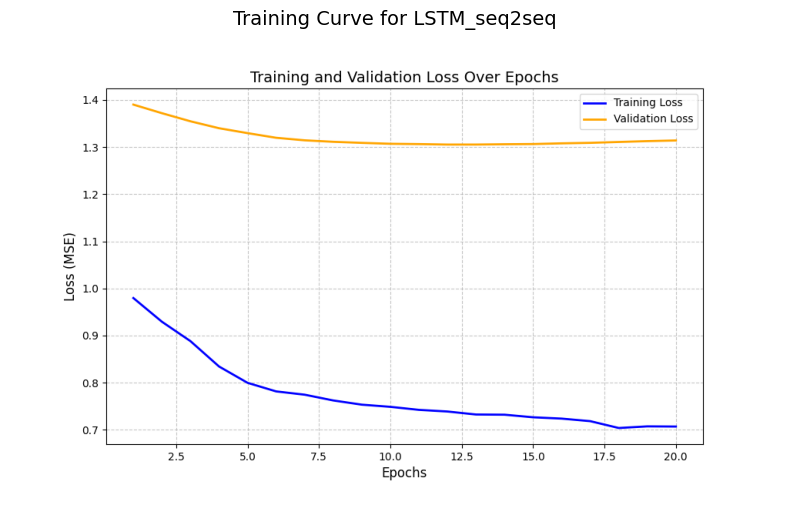

In [108]:
# load the png image of the training curve and display it
current_dir = "Thibaut_regressive"
img_path = os.path.join(current_dir, f'curves_{id}_{L}_{n}_{n_layers}_{hidden_dim}_{lr}.png')
if os.path.exists(img_path):
    img = plt.imread(img_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Training Curve for {id}", fontsize=14)
    plt.show()
else:
    print(f"Error: Training curve image not found at {img_path}")

## 7. **Inference**

### 7.1 Specify the model path

In [110]:
model_path = "best_10_L18_n12_layers1_hidden32.pth"
id = "10"
if not os.path.exists(model_path):
    print(f"Error: Weights file not found at {model_path}")
    exit()

### 7.2 Initialization of data and the model

In [111]:
loaders = {
    "Train": DataLoader(train_subset, batch_size=batch_size, shuffle=False),
    "Val": DataLoader(val_subset, batch_size=batch_size, shuffle=False),
    "Test": DataLoader(test_subset, batch_size=batch_size, shuffle=False)
}

# Setup model dimensions
target_col = 'avg_delay'
target_idx = full_ds.column_to_idx[target_col]
sample_x, _, _ = full_ds[0]
input_dim = sample_x.shape[1]

# Initialize and load model
model = LSTMSeq2Seq(
    input_dim=input_dim, 
    hidden_dim=hidden_dim, 
    target_idx=target_idx, 
    output_dim=1, 
    n_layers=n_layers
).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
criterion = nn.MSELoss()

print("--- Inference & Evaluation Mode ---")
print(f"Loading weights from: {model_path}")


--- Inference & Evaluation Mode ---
Loading weights from: best_10_L18_n12_layers1_hidden32.pth


### 7.3 Calculate the loss and collect data for plotting

In [112]:
results = {}
plot_data = {name: {"preds": [], "trues": [], "separators": []} for name in loaders.keys()}
metric_data = {name: {"preds": [], "trues": []} for name in loaders.keys()}

for name, loader in loaders.items():
    total_loss = 0
    global_idx = 0
    prev_ts = None
    
    with torch.no_grad():
        for x_past, target_window, target_timestamp in tqdm(loader, desc=f"Evaluating {name}"):
            x_past, target_window = x_past.to(device), target_window.to(device)
            
            # Inference (TF=0)
            y_pred_tensor = model(x_past, target_window, teacher_forcing_ratio=0)
            y_true_tensor = target_window[:, :, target_idx].unsqueeze(-1)

            loss = criterion(y_pred_tensor, y_true_tensor)
            total_loss += loss.item()
            
            # Denormalize
            y_pred = denormalize_prediction(y_pred_tensor, train_subset.scaler, target_idx, input_dim)
            y_true = denormalize_prediction(y_true_tensor, train_subset.scaler, target_idx, input_dim)

            horizon_idx = n - 1 
            preds_batch = y_pred[:, horizon_idx]
            trues_batch = y_true[:, horizon_idx]
            
            
            # Track segment transitions using timestamps
            for i, ts_str in enumerate(target_timestamp):
                current_ts = pd.to_datetime(ts_str)
                if prev_ts is not None:
                    # If gap > 1 hour or time goes backwards, it's a new segment
                    diff = (current_ts - prev_ts).total_seconds()
                    if diff > 3600 or diff < 0:
                        plot_data[name]["separators"].append(global_idx + i)
                prev_ts = current_ts
            plot_data[name]["preds"].extend(preds_batch)
            plot_data[name]["trues"].extend(trues_batch)
            metric_data[name]["preds"].extend(y_pred)
            metric_data[name]["trues"].extend(y_true)
            
            global_idx += len(preds_batch)
    
    avg_loss = total_loss / len(loader)
    results[name] = avg_loss


Evaluating Test: 100%|██████████| 20/20 [00:00<00:00, 112.59it/s]


### 7.4 Plotting the subplots (segments are separated by a red vertical dot line)

Inference subplot saved at: Thibaut_regressive/inference_subplots_10.png


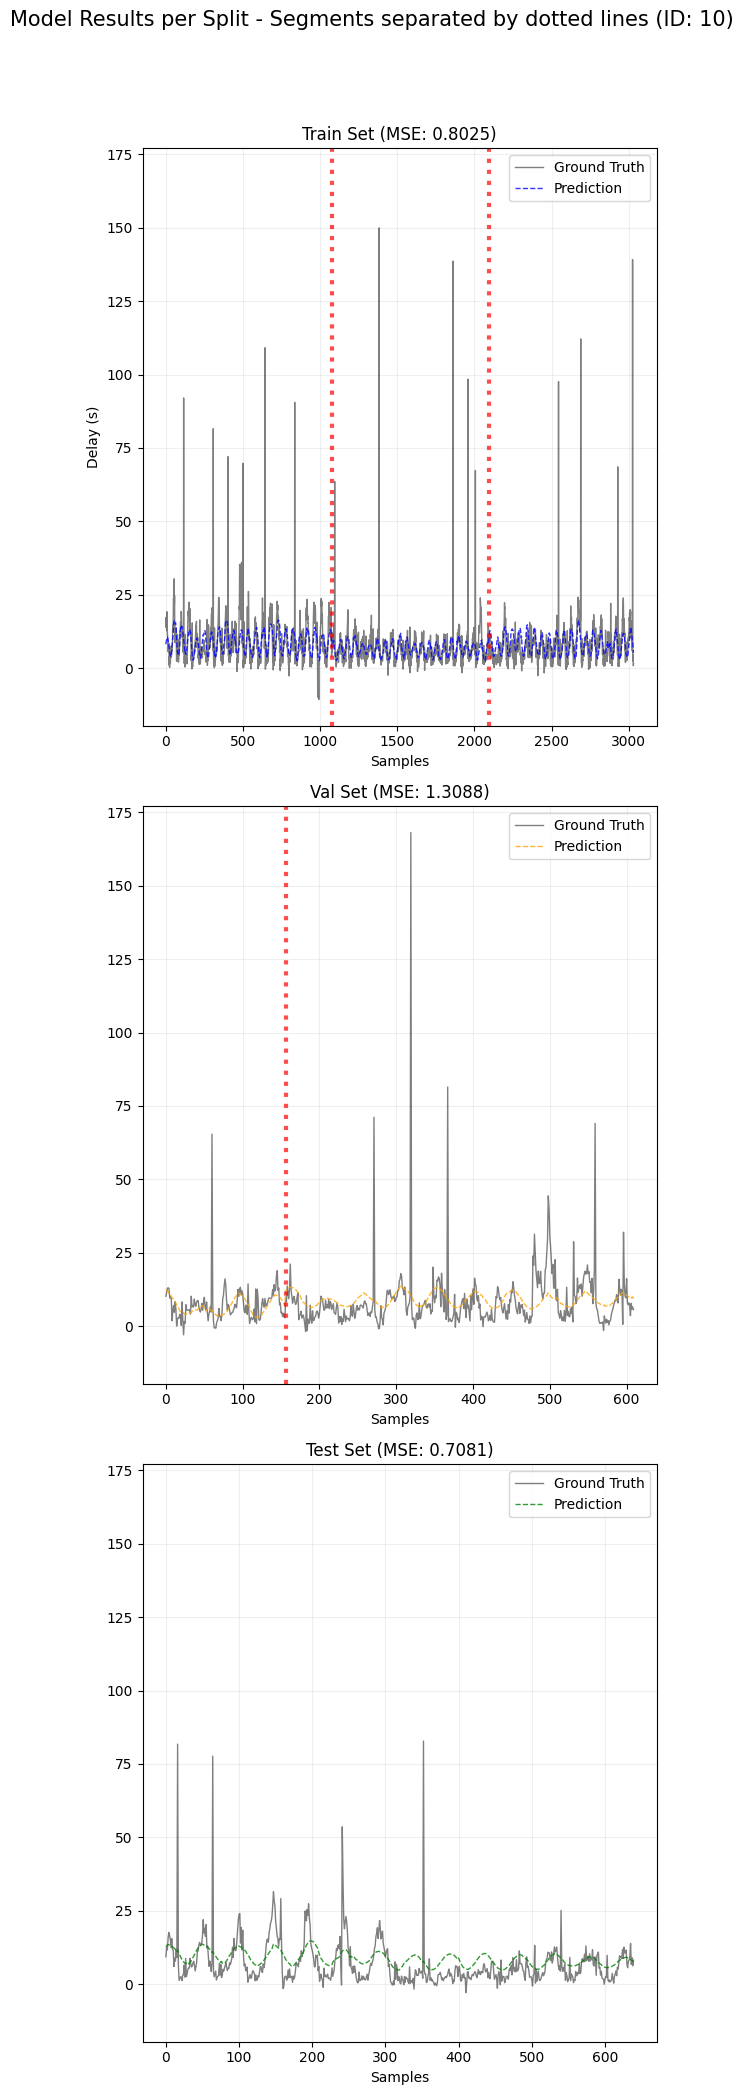

In [113]:
fig, axes = plt.subplots(3, 1, figsize=(6, 22), sharey=True)
dataset_names = ["Train", "Val", "Test"]
colors = ['blue', 'orange', 'green']

for i, name in enumerate(dataset_names):
    data = plot_data[name]
    axes[i].plot(data["trues"][:], label="Ground Truth", color='black', alpha=0.5, lw=1)
    axes[i].plot(data["preds"][:], label="Prediction", color=colors[i], linestyle='--', alpha=0.8, lw=1)
    
    # Add vertical dotted lines for segment separators
    for sep in data["separators"]:
        axes[i].axvline(x=sep, color='red', linestyle=':', linewidth=3, alpha=0.7)
        
    axes[i].set_title(f"{name} Set (MSE: {results[name]:.4f})")
    axes[i].set_xlabel("Samples")
    if i == 0:
        axes[i].set_ylabel("Delay (s)")
    axes[i].legend()
    axes[i].grid(True, alpha=0.2)

plt.suptitle(f"Model Results per Split - Segments separated by dotted lines (ID: {id})", fontsize=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plot_save_path = f"Thibaut_regressive/inference_subplots_{id}.png"
plt.savefig(plot_save_path)
print(f"Inference subplot saved at: {plot_save_path}")
plt.show()

### 7.5 Metrics on the predictions

In this section, we calculate different metrics based on our predictions at horizon t+1, t+2, ... t+12 (timestep is 30 mins). The different metrics we will evaluate our predictions on are :   

**Regression metrics** :     

* MSE : Mean Squared Error
* RMSE : Root Mean Squared Error
* MAE : Mean Absolute Error

**Binary classification metrics**. To this end, we use a delay disruption threshold past which we consider the bus line to be disrupted :    

* Precision
* Recall
* R2
* F1 score 

In [114]:
DISRUPTION_THR = 10 # threshold of 10 min

In [150]:
# Required parameters for evaluation
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, drop_last=False)
input_dim = bus_df.select_dtypes(include=[np.number]).shape[1] 
target_idx = full_ds.column_to_idx['avg_delay']

# Evaluate and save metrics by horizon to CSV
results_df = evaluate_to_metrics_by_horizon(
    model=model,
    test_loader=test_loader, 
    scaler=test_subset.scaler,          
    device=device,
    target_idx=target_idx,
    input_dim=input_dim,
    disruption_thr=DISRUPTION_THR,
    n_horizons=n,
    output_filename="results_LSTM.csv"
)

results_df.head(12)

Export done : 12 horizons saved in results_LSTM.csv


,Horizon,MSE,RMSE,MAE,R2,Precision,Recall,F1
0,1,44.5091,6.6715,3.5852,0.3009,0.7674,0.6972,0.7306
1,2,45.1285,6.7178,3.8137,0.2902,0.6981,0.7817,0.7375
2,3,46.5440,6.8223,4.0653,0.2670,0.6512,0.7943,0.7157
3,4,47.6810,6.9051,4.2309,0.2490,0.6042,0.8227,0.6967
4,5,48.5288,6.9663,4.3306,0.2355,0.5842,0.8369,0.6880
5,6,49.1005,7.0072,4.3903,0.2262,0.5771,0.8286,0.6804
6,7,49.5843,7.0416,4.4303,0.2187,0.5707,0.8071,0.6686
7,8,50.0203,7.0725,4.4639,0.2127,0.5751,0.7872,0.6647
8,9,50.3357,7.0948,4.4858,0.2077,0.5914,0.7801,0.6728
9,10,50.6205,7.1148,4.4986,0.2033,0.6022,0.7730,0.6770
